In [1]:
import os
import numpy as np
import polars as pl
import tensorflow as tf
import sys
from pathlib import Path

repo_root = Path().resolve().parents[3]
sys.path.insert(0, str(repo_root))

from src.preprocessing.preprocessing import processor
from src.models.lstm import LSTMModel
from src.utils.helpers import create_sequences

In [2]:
STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg"
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

WINDOW_SIZE = 72

config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "file_path": "flood-dataset-top30",
    "file_name": "flood_model_top30",
    "table": "wandb.flood_model_top30",
    "lag_window": 1,
    "frequency": "hourly",
    "split_time_days": 30,
    "site_scaling": False,
}

In [3]:
pcr = processor(config)
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()
X_test, y_test, test_site_ids = create_sequences(test_X, test_y, WINDOW_SIZE)
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-top30:latest', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.6 (238.4MB/s)


Starting preprocessing: 4,818,417 rows, 31 columns
After lag null removal: 3,412,815 rows, 28 features
Splitting by time...
Train: 2,730,278 | Val: 341,318 | Test: 341,219
Scaling features and targets...
Scaling complete.
shape: (37,)
Series: 'site_id' [str]
[
	"06450500"
	"06803495"
	"06820500"
	"06803513"
	"06061500"
	…
	"06188000"
	"06803500"
	"06465700"
	"06700000"
	"06881000"
]
(4818417, 31)
X_test shape: (338699, 72, 28)
y_test shape: (338699,)


In [ ]:
_tmp = LSTMModel()
asymmetric_mse = _tmp._loss()

model = LSTMModel.load_model(
    "lstm_model2.keras",
    custom_objects={"asymmetric_mse": asymmetric_mse}
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 72, 32)         │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,293 (141.77 KB)

 Trainable params: 12,097 (47.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,196 (94.52 KB)

In [6]:
model.evaluate(X_test, y_test)

Test mse: 0.2439  |  MAE (scaled): 0.1140


In [7]:
from src.postprocessing.postprocessing import PostProcessor

pp = PostProcessor(
    model=model,
    X_test=X_test,
    y_test=y_test,
    site_ids=test_site_ids,
    target_scaler=pcr.target_scaler,
    feature_names=DYNAMIC_FEATURES + STATIC_FEATURES,
)

c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10585/10585 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step
Overall test mse: 0.2439  |  MAE (scaled): 0.1140

Site 06036650:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             2029.4 CFS       1944.1 CFS    204.8 CFS


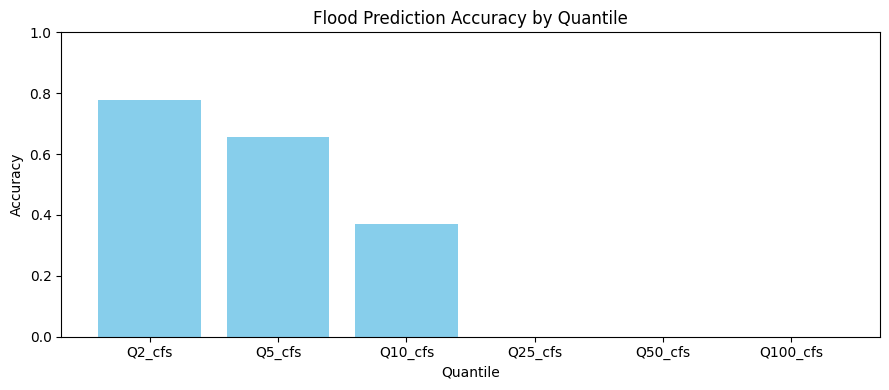


Site 06061500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               54.8 CFS         76.7 CFS     26.2 CFS


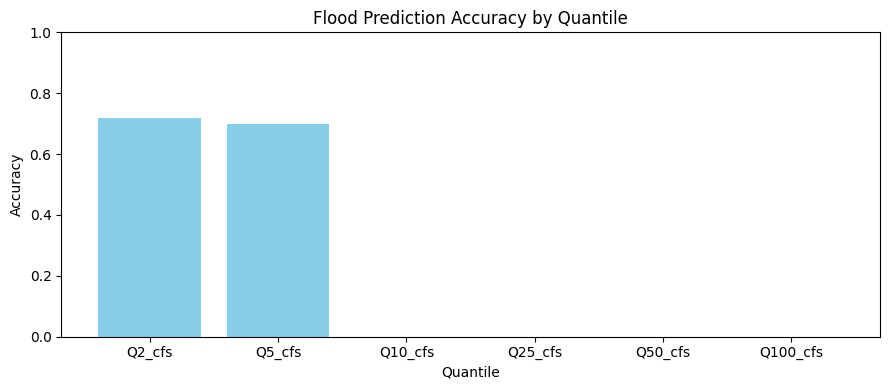


Site 06093200:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              202.0 CFS        208.2 CFS     51.6 CFS


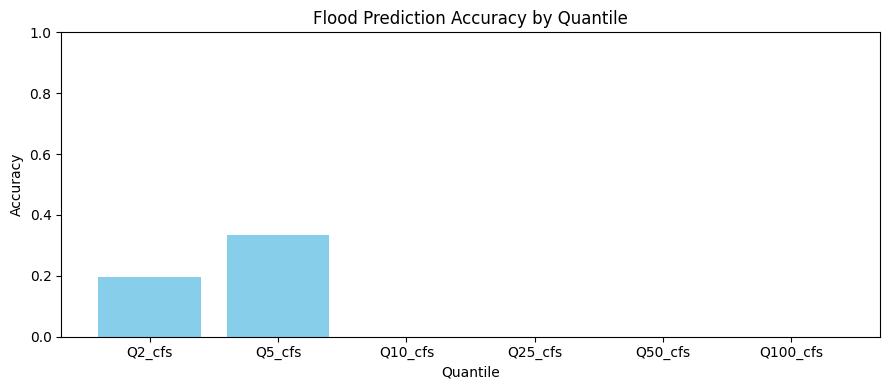


Site 06188000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1434.5 CFS       1454.0 CFS    245.9 CFS


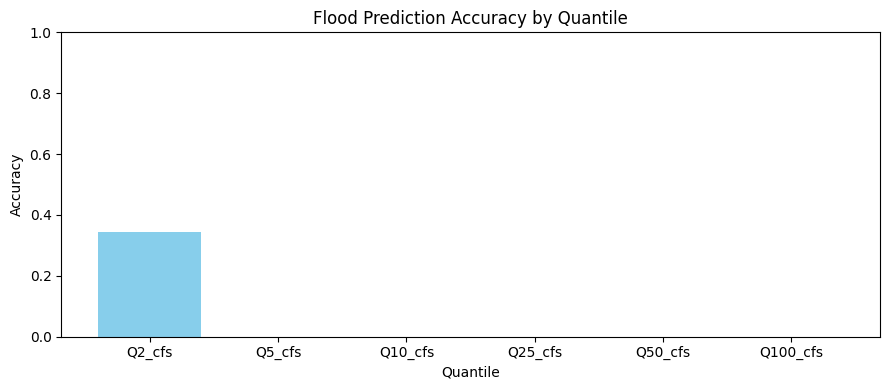


Site 06207500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1143.6 CFS       1132.3 CFS    164.3 CFS


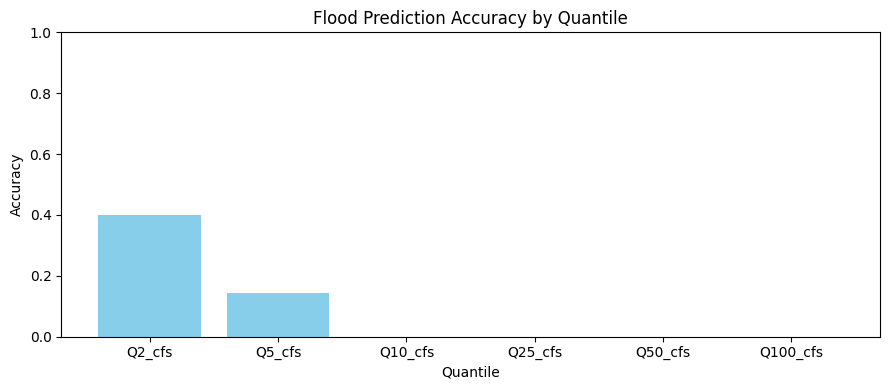


Site 06211000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              104.2 CFS        117.9 CFS     33.0 CFS


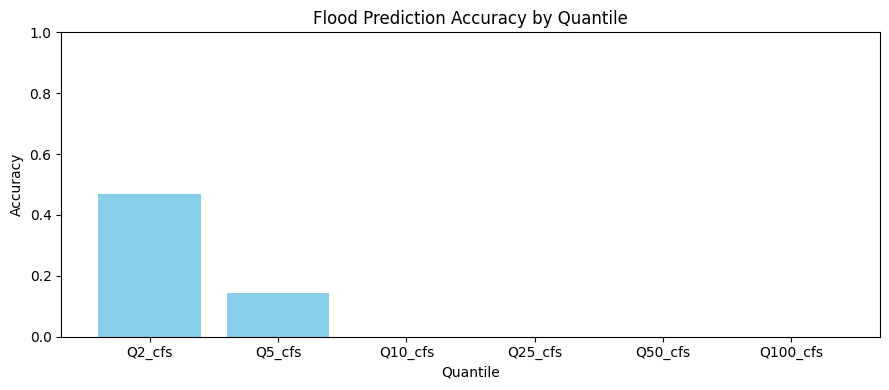


Site 06308500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              539.0 CFS        536.5 CFS     92.7 CFS


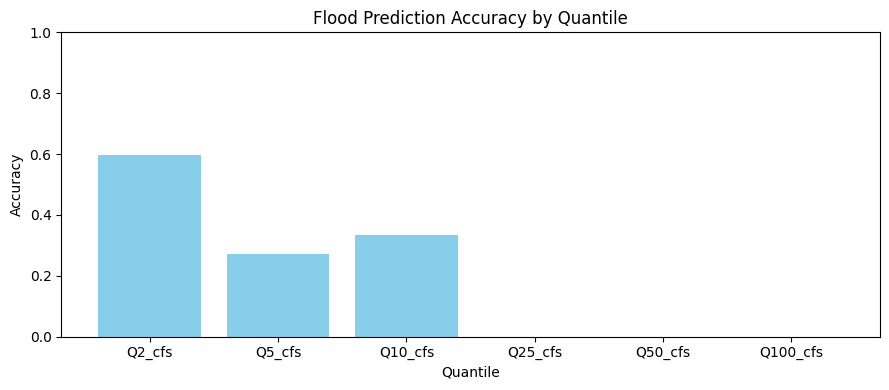


Site 06440200:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               23.4 CFS         25.2 CFS     35.4 CFS


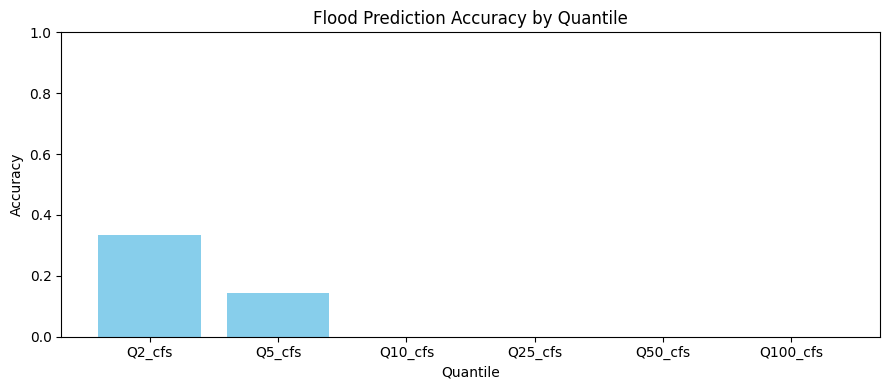


Site 06446700:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               27.1 CFS         46.7 CFS     31.1 CFS


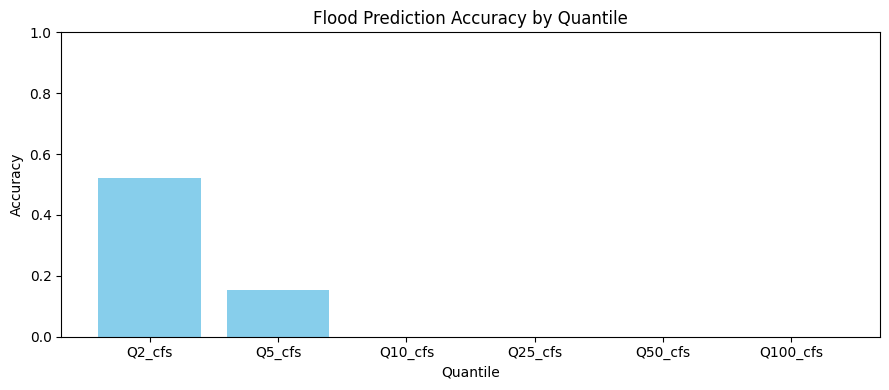


Site 06447500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               36.2 CFS         38.8 CFS     22.1 CFS


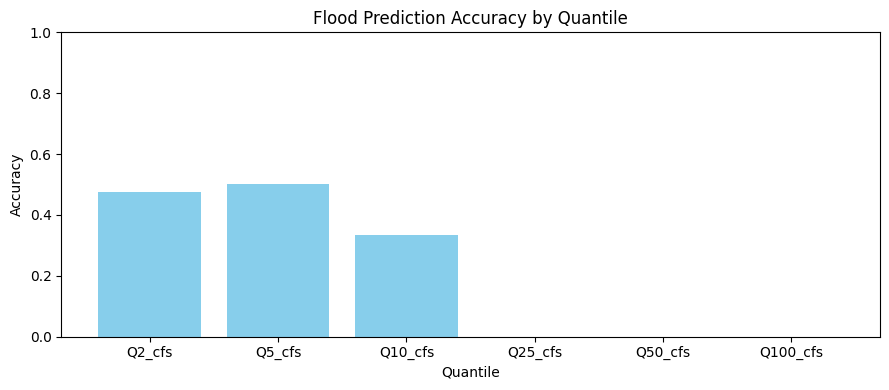


Site 06449000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               34.7 CFS         24.8 CFS     24.2 CFS


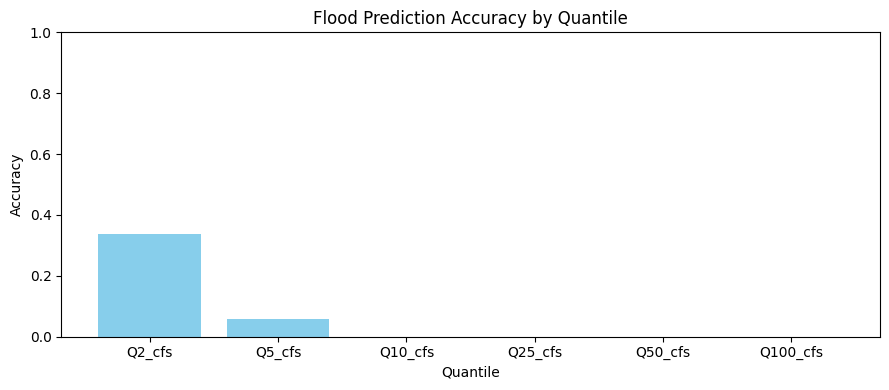


Site 06450500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              243.2 CFS        243.8 CFS     48.1 CFS


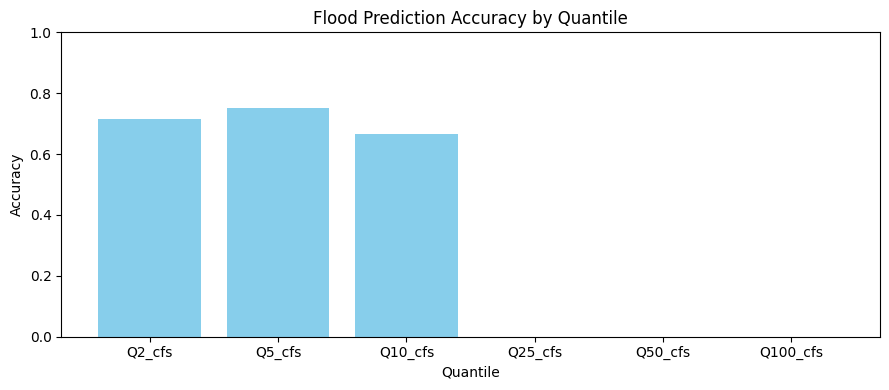


Site 06464100:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               66.6 CFS         75.3 CFS     30.2 CFS


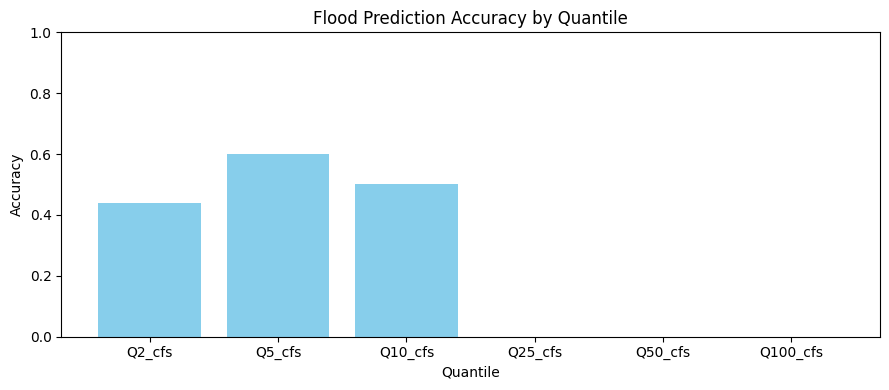


Site 06465700:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              179.7 CFS        170.0 CFS     48.1 CFS


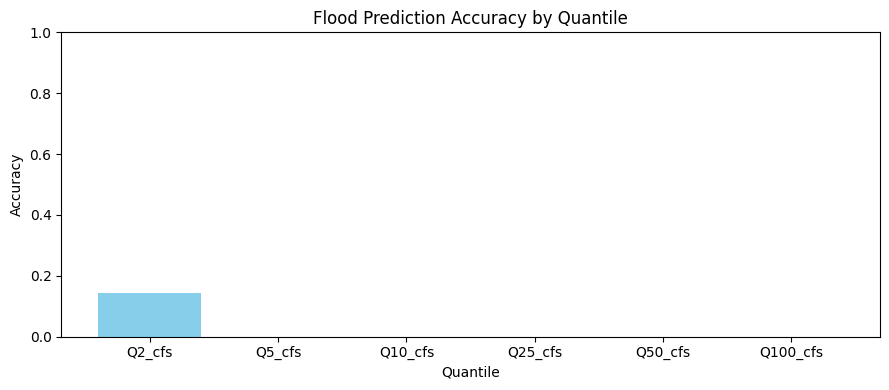


Site 06700000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              200.8 CFS        196.1 CFS     39.5 CFS


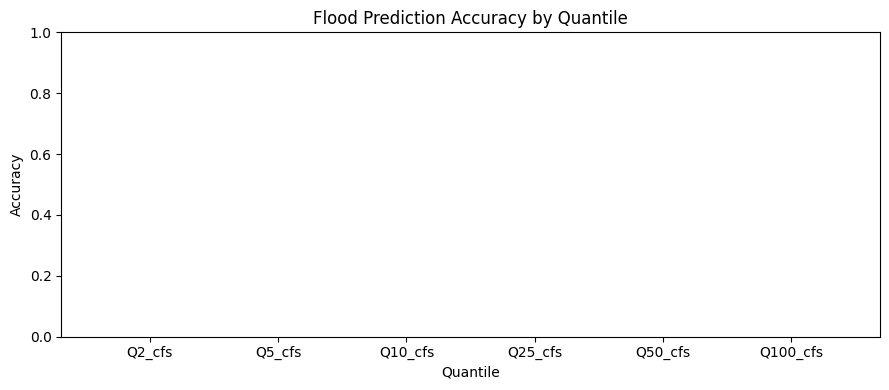


Site 06710385:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               42.7 CFS         86.9 CFS     46.5 CFS


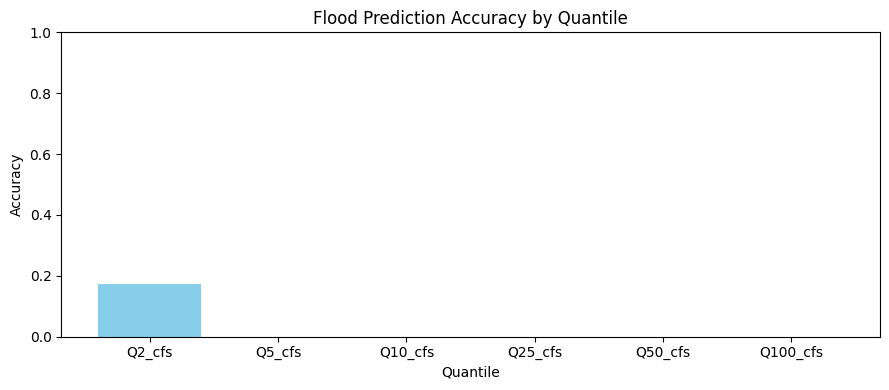


Site 06784000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              235.6 CFS        229.9 CFS     56.5 CFS


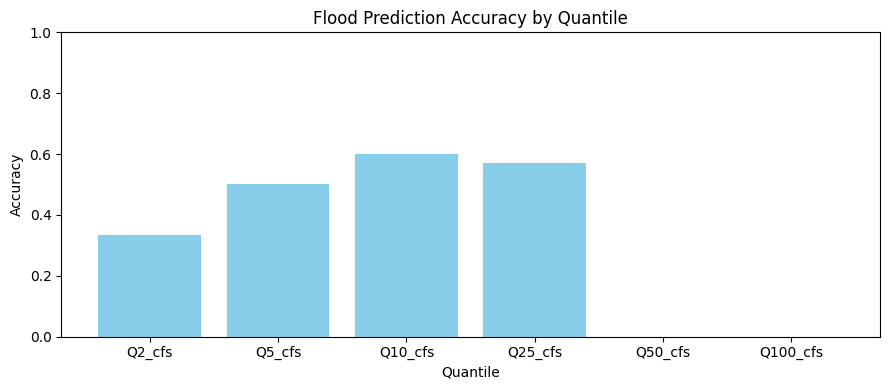


Site 06793000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1162.3 CFS       1119.6 CFS    489.5 CFS


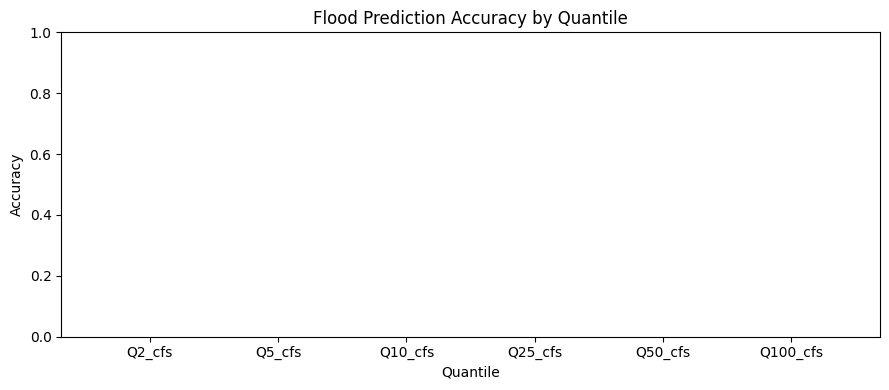


Site 06799100:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              201.2 CFS        179.3 CFS     62.1 CFS


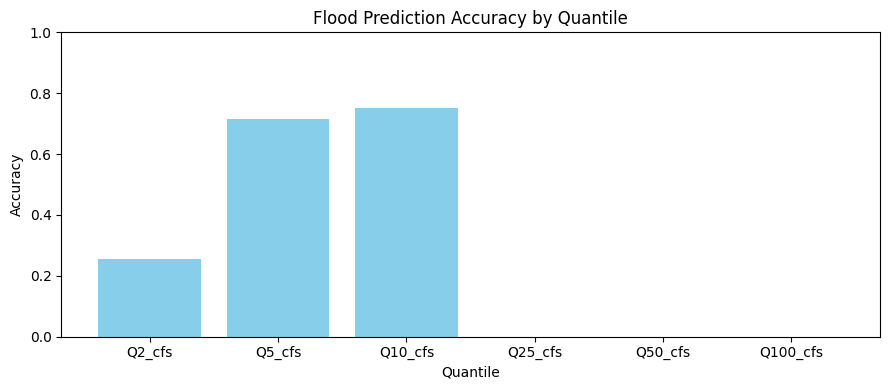


Site 06799315:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1190.1 CFS       1076.7 CFS    213.0 CFS


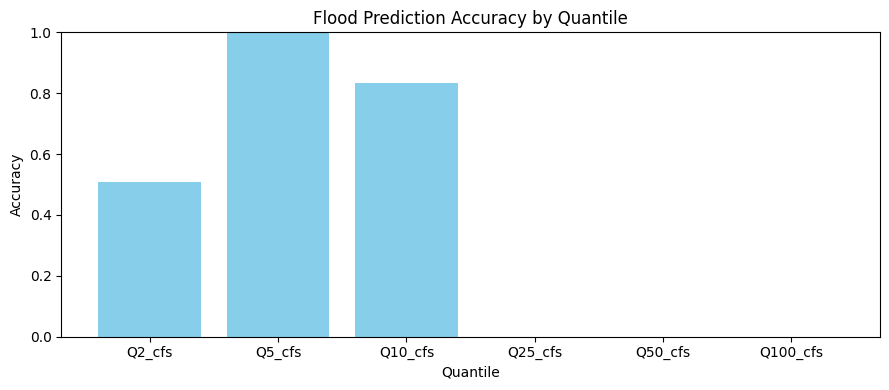


Site 06803495:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              250.8 CFS        241.2 CFS    151.9 CFS


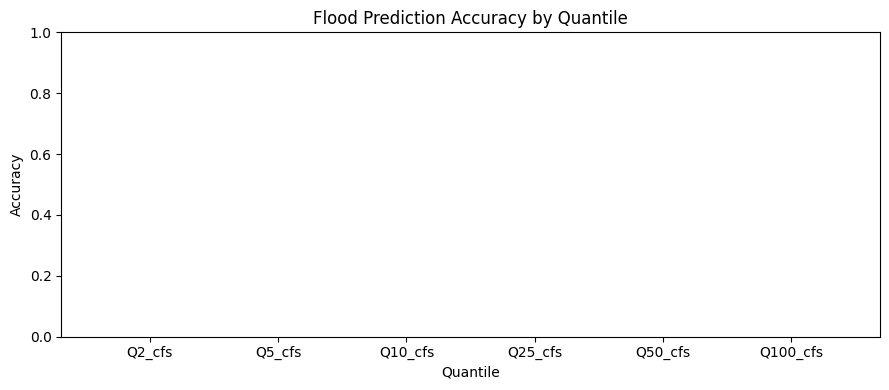


Site 06803500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              272.5 CFS        267.2 CFS    148.9 CFS


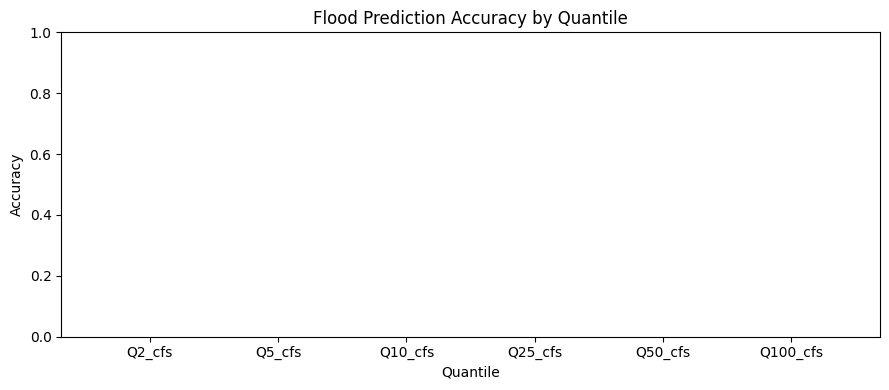


Site 06820500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1379.4 CFS       1248.0 CFS    606.7 CFS


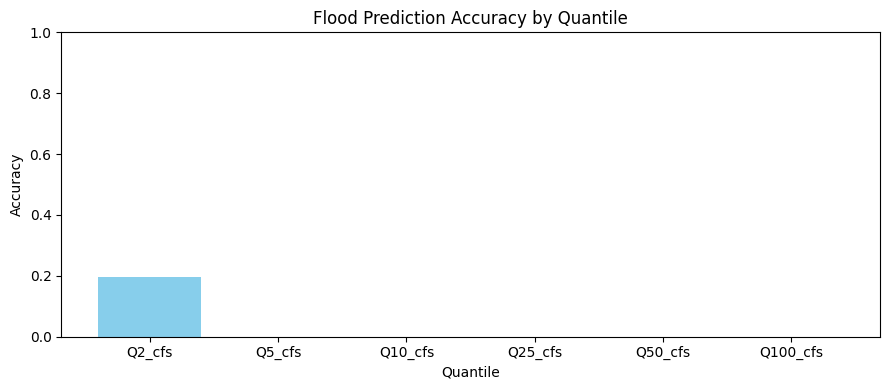


Site 06821500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test                2.4 CFS         31.9 CFS     30.1 CFS


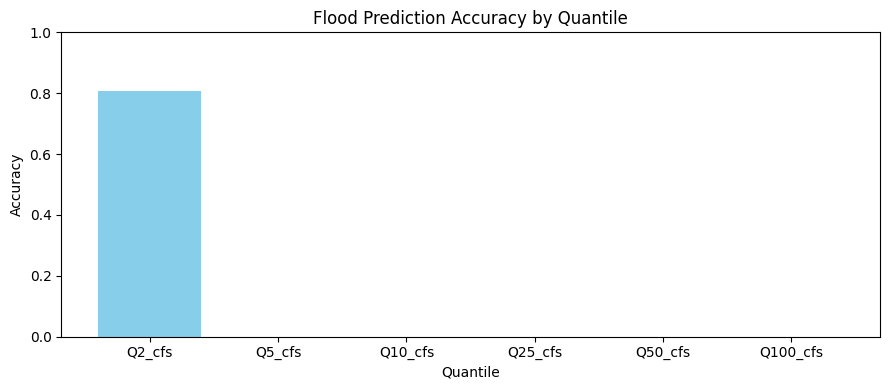


Site 06834000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               20.6 CFS         37.2 CFS     20.5 CFS


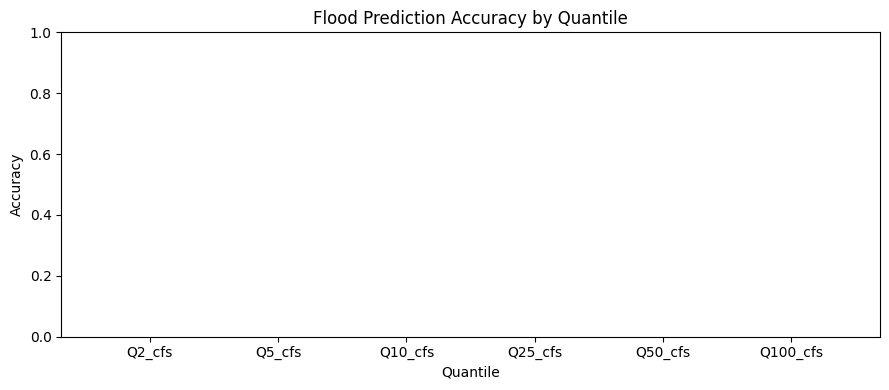


Site 06838000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               12.7 CFS         30.6 CFS     25.2 CFS


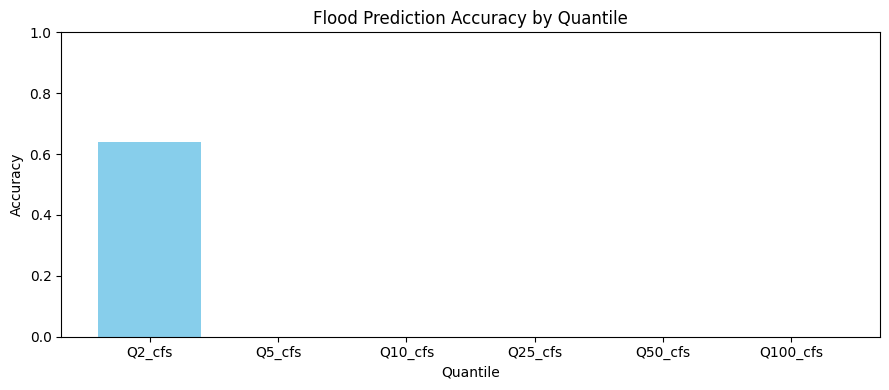


Site 06869950:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               38.8 CFS         80.4 CFS     74.8 CFS


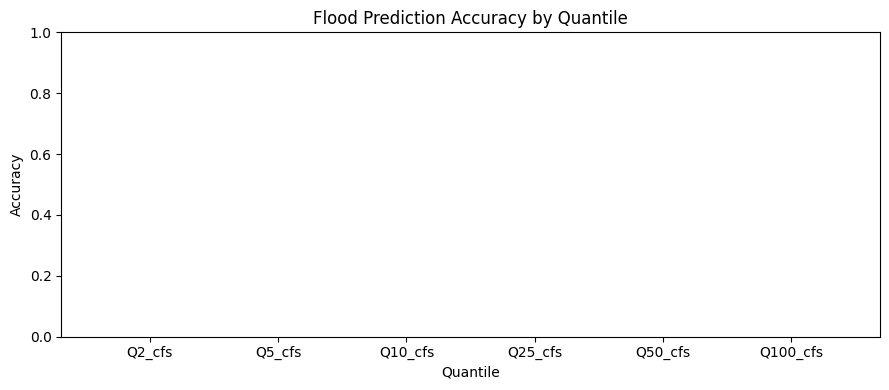


Site 06881000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              447.5 CFS        401.6 CFS    161.8 CFS


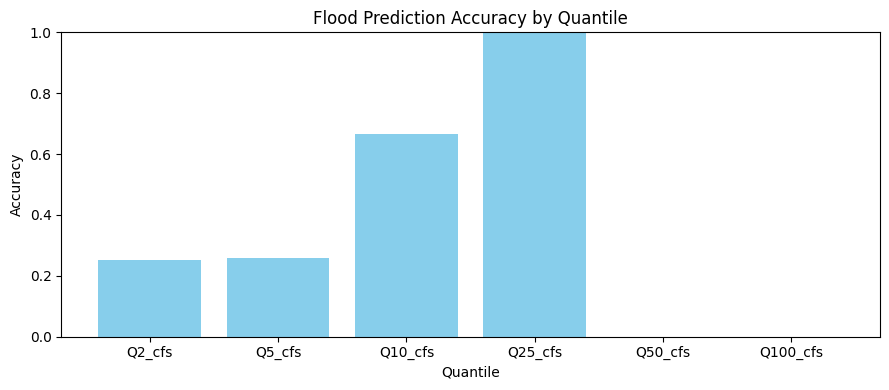


Site 06895000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              158.6 CFS        164.9 CFS    153.7 CFS


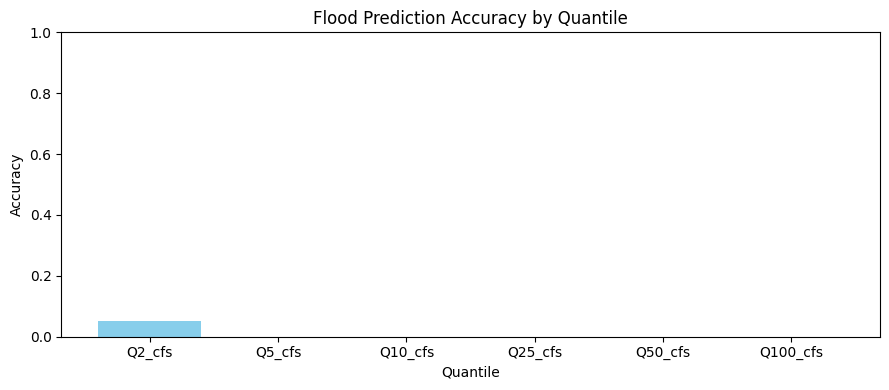


Site 06909500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               86.4 CFS        130.1 CFS    135.9 CFS


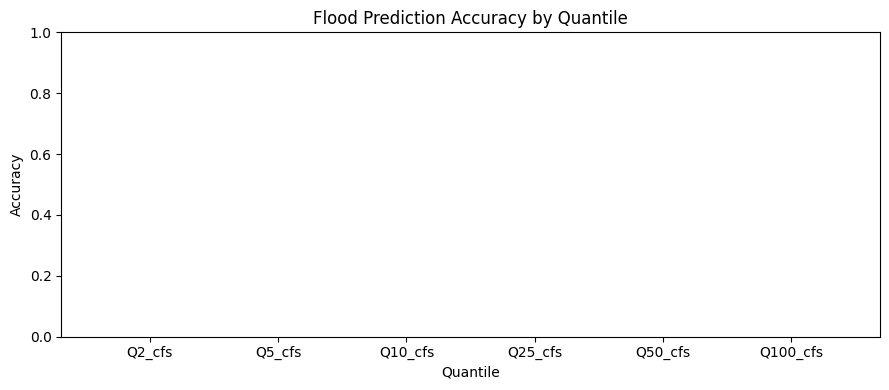


Site 06917000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              308.6 CFS        275.6 CFS    262.2 CFS


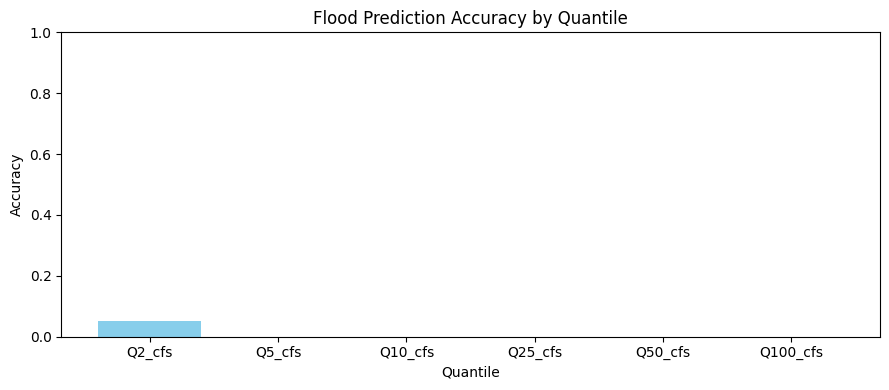


Site 06917060:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              481.3 CFS        477.6 CFS    281.4 CFS


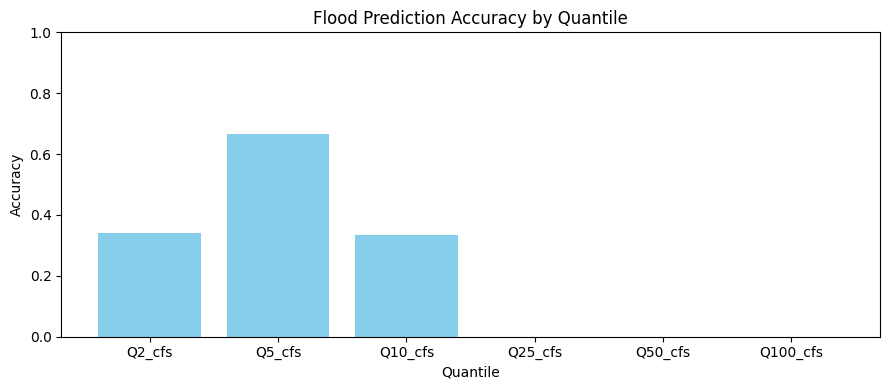


Site 06921590:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              297.0 CFS        277.1 CFS    279.1 CFS


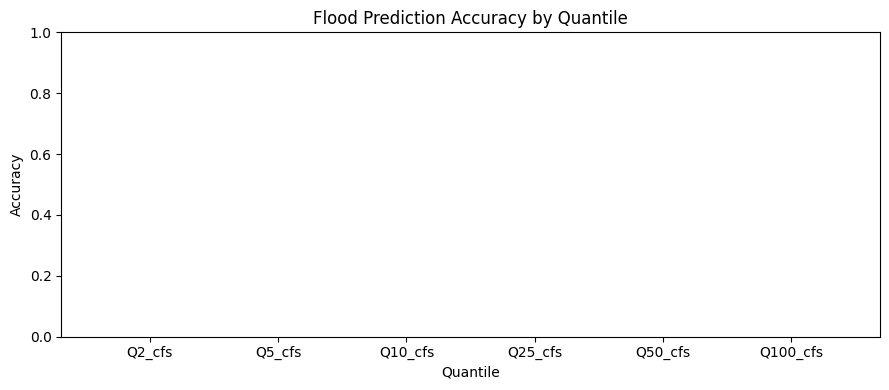


Site 06935755:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test                4.1 CFS         38.0 CFS     37.5 CFS


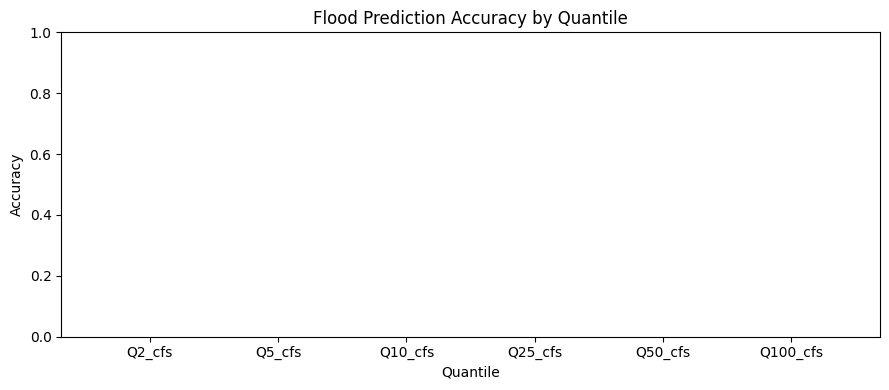


Site 06935955:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               20.5 CFS         42.6 CFS     47.1 CFS


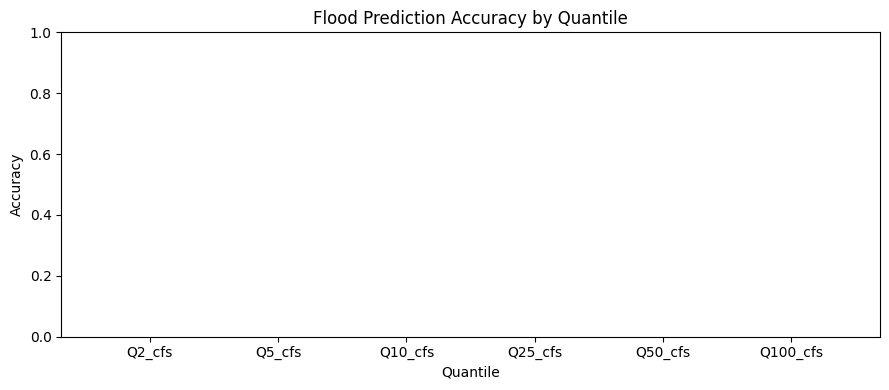

In [8]:
pp.evaluate()

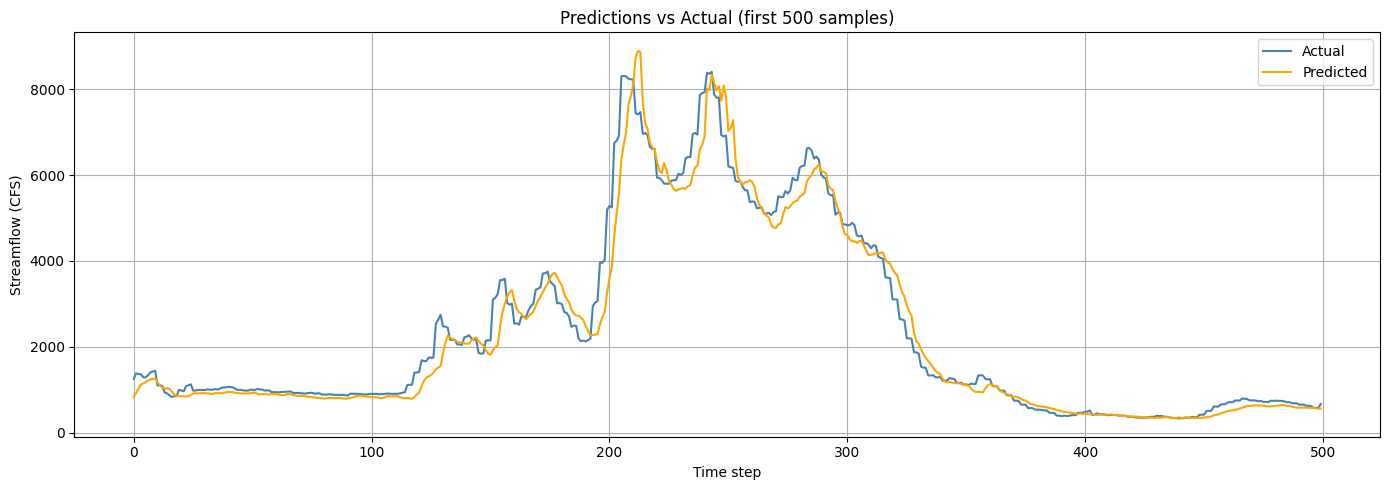

In [9]:
pp.plot_results()

In [10]:
pp.persistence_baseline()

Model                   MAE (scaled)   RMSE (scaled)        NSE
--------------------------------------------------------------
Persistence                   0.0968          0.5559     0.6955
Model                         0.1140          0.4939     0.7597


Subsampling X_test from 338699 to 300 samples for SHAP...
Computing SHAP values via KernelSHAP (nsamples=200)...


 99%|█████████▉| 297/300 [10:38<00:06,  2.16s/it]c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=8.930e-02, with an active set of 3 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
100%|██████████| 300/300 [10:45<00:00,  2.15s/it]


Done.


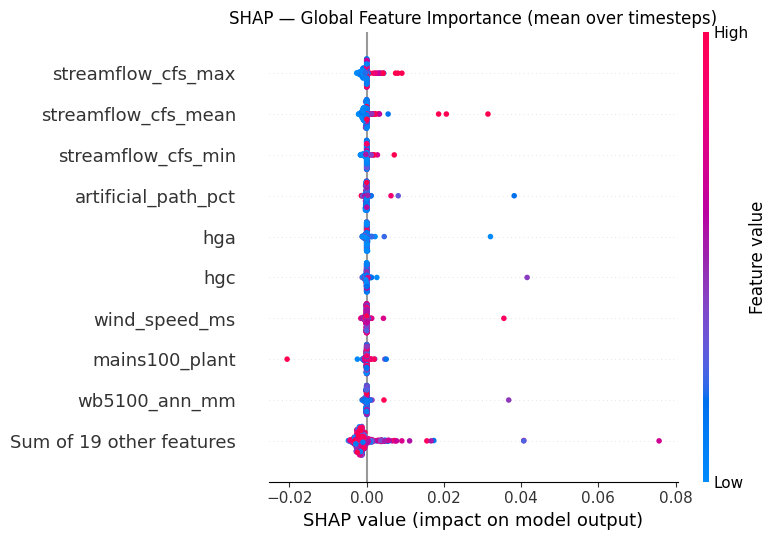

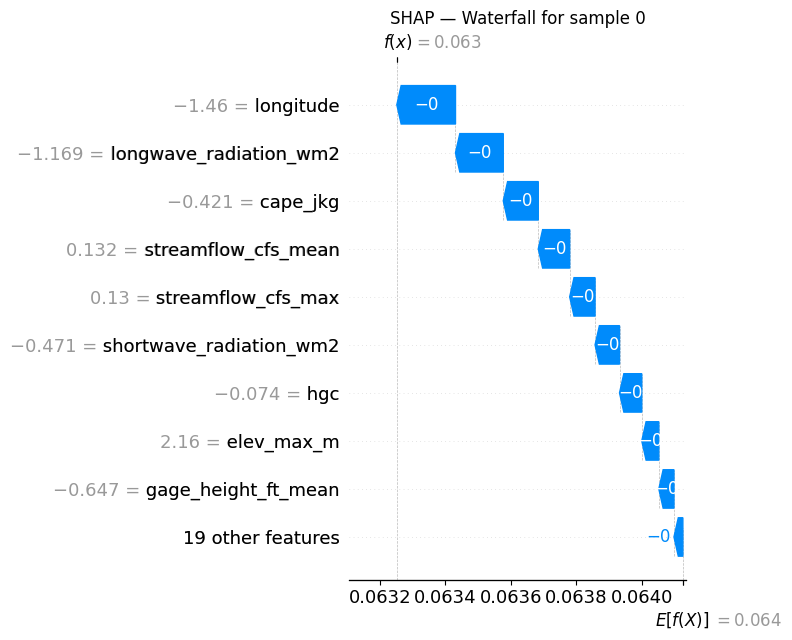

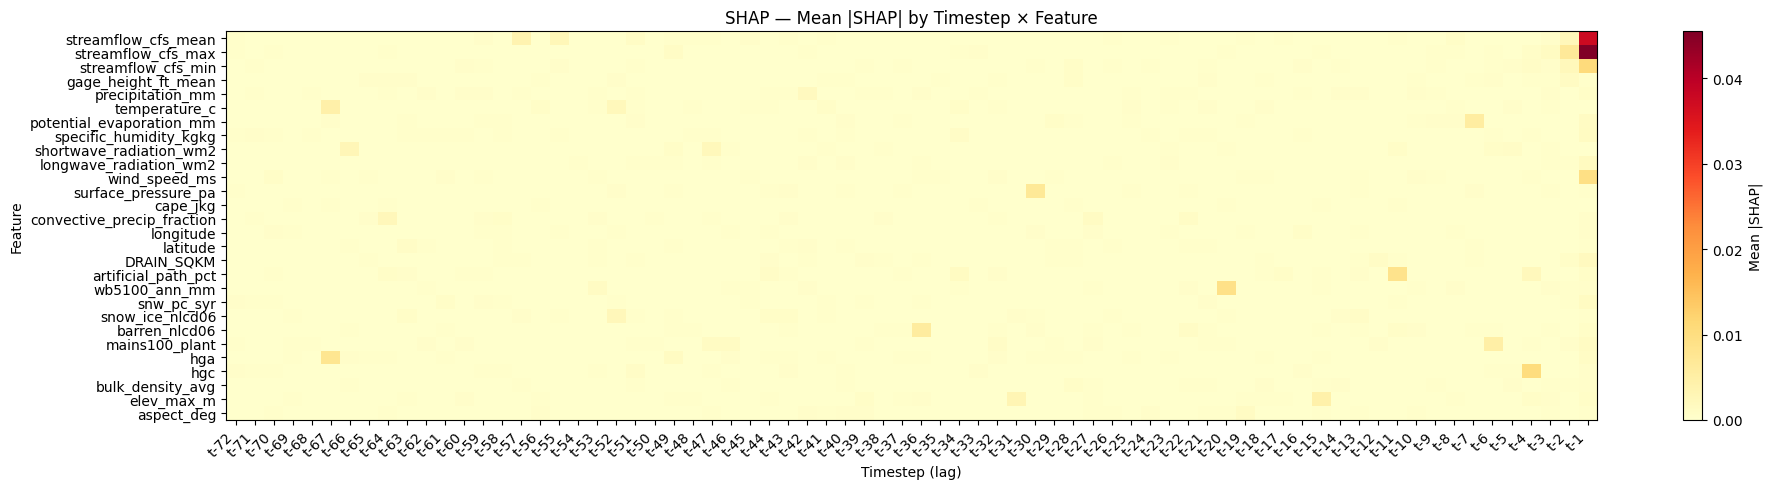

In [11]:
pp.compute_shap()